# Hospital Performance Analysis: CMS HVBP Score Prediction

**Research Question:** What drives hospital performance? Analyzing the role of patient experiences in predicting hospital success.

## 1. Setup and Data Loading

In [1]:
# Import necessary libraries
# Data Manipulation Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set visualization style for consistency
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load datasets from GitHub repository
# We focus on TPS (Total Performance Score) and HCAHPS (patient satisfaction) datasets
base_url = 'https://raw.githubusercontent.com/osoliman/Chapter6_HTM737/refs/heads/main/'

df_tps = pd.read_csv(f'{base_url}hvbp_tps_11_07_2017.csv')
df_hcahps = pd.read_csv(f'{base_url}hvbp_hcahps_11_07_2017.csv')

print(f"TPS data: {df_tps.shape}")
print(f"HCAHPS data: {df_hcahps.shape}")

TPS data: (2808, 16)
HCAHPS data: (2808, 73)


## 2. Data Preparation
Instead of loading all columns, we carefully select only the relevant columns needed for analysis. This keeps the dataset clean and focused on our research question.

In [3]:
# Select only relevant columns from TPS dataset
# We need:
# - Identifiers: Provider Number, Hospital Name, State, County
# - Target variable: Total Performance Score
# - Features: Four domain scores that make up the total score
tps_cols = ['Provider Number', 'Hospital Name', 'State', 'County Name',
            'Total Performance Score',
            'Weighted Normalized Clinical Care Domain Score',
            'Weighted Patient and Caregiver Centered Experience of Care/Care Coordination Domain Score',
            'Weighted Safety Domain Score',
            'Weighted Efficiency and Cost Reduction Domain Score']

df_analysis = df_tps[tps_cols].copy()

# Rename columns for easier handling and readability
df_analysis = df_analysis.rename(columns={
    'Total Performance Score': 'Total_Performance_Score',
    'Weighted Normalized Clinical Care Domain Score': 'Clinical_Care_Score',
    'Weighted Patient and Caregiver Centered Experience of Care/Care Coordination Domain Score': 'Patient_Experience_Score',
    'Weighted Safety Domain Score': 'Safety_Score',
    'Weighted Efficiency and Cost Reduction Domain Score': 'Efficiency_Score'
})

# Convert string values to numeric (some may be stored as text)
numeric_cols = ['Total_Performance_Score', 'Clinical_Care_Score', 
                'Patient_Experience_Score', 'Safety_Score', 'Efficiency_Score']
for col in numeric_cols:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

print(f"Dataset prepared: {df_analysis.shape}")

Dataset prepared: (2808, 9)


In [4]:
# Prepare HCAHPS data (patient satisfaction scores)
hcahps_cols = ['Provider Number', 'HCAHPS Base Score', 'HCAHPS Consistency Score']
df_hcahps_clean = df_hcahps[hcahps_cols].copy()

# Convert to numeric
df_hcahps_clean['HCAHPS Base Score'] = pd.to_numeric(df_hcahps_clean['HCAHPS Base Score'], errors='coerce')
df_hcahps_clean['HCAHPS Consistency Score'] = pd.to_numeric(df_hcahps_clean['HCAHPS Consistency Score'], errors='coerce')

# Calculate total HCAHPS score (Base + Consistency)
df_hcahps_clean['HCAHPS_Score'] = df_hcahps_clean['HCAHPS Base Score'] + df_hcahps_clean['HCAHPS Consistency Score']

# Merge with main dataset
df_analysis = df_analysis.merge(df_hcahps_clean[['Provider Number', 'HCAHPS_Score']],  # merge only necessary columns
                                on='Provider Number', how='left')

print(f"After merge: {df_analysis.shape}")

After merge: (2808, 10)


In [5]:
# Get all rows with any missing values in our key columns
key_columns = ['Total_Performance_Score', 'HCAHPS_Score', 'Clinical_Care_Score', 
               'Safety_Score', 'Efficiency_Score', 'Patient_Experience_Score']

# Find rows with at least one missing value
rows_with_missing = df_analysis[df_analysis[key_columns].isnull().any(axis=1)]

print(f"Total rows with missing data: {len(rows_with_missing)}")
print(f"Total rows in dataset: {len(df_analysis)}")
print(f"Percentage with missing data: {len(rows_with_missing)/len(df_analysis)*100:.2f}%")
print("\n" + "="*100)

# Display all rows with missing values
display_columns = ['Provider Number', 'Hospital Name', 'State', 'County Name',
                   'Total_Performance_Score', 'HCAHPS_Score', 'Clinical_Care_Score', 
                   'Safety_Score', 'Efficiency_Score', 'Patient_Experience_Score']

print("\nAll hospitals with missing data:")
print("="*100)

for idx, row in rows_with_missing.iterrows():
    print(f"\nRow {idx}:")
    print(f"Provider: {row['Provider Number']} | Hospital: {row['Hospital Name']}")
    print(f"Location: {row['County Name']}, {row['State']}")
    print(f"Total Performance Score: {row['Total_Performance_Score']}")
    print(f"HCAHPS Score: {row['HCAHPS_Score']}")
    print(f"Clinical Care Score: {row['Clinical_Care_Score']}")
    print(f"Safety Score: {row['Safety_Score']}")
    print(f"Efficiency Score: {row['Efficiency_Score']}")
    print(f"Patient Experience Score: {row['Patient_Experience_Score']}")
    print("-"*100)

Total rows with missing data: 274
Total rows in dataset: 2808
Percentage with missing data: 9.76%


All hospitals with missing data:

Row 3:
Provider: 10007 | Hospital: MIZELL MEMORIAL HOSPITAL
Location: Covington, AL
Total Performance Score: 27.555555555556
HCAHPS Score: 56.0
Clinical Care Score: 8.888888888889
Safety Score: nan
Efficiency Score: 0.0
Patient Experience Score: 18.666666666667
----------------------------------------------------------------------------------------------------

Row 8:
Provider: 10021 | Hospital: DALE MEDICAL CENTER
Location: Dale, AL
Total Performance Score: 36.333333333333
HCAHPS Score: 64.0
Clinical Care Score: 5.0
Safety Score: nan
Efficiency Score: 10.0
Patient Experience Score: 21.333333333333
----------------------------------------------------------------------------------------------------

Row 9:
Provider: 10022 | Hospital: CHEROKEE MEDICAL CENTER
Location: Cherokee, AL
Total Performance Score: 34.333333333333
HCAHPS Score: 53.0
Clinical Care Sc

### Handling Missing Values

- We observed that ~10% of hospitals have one missing domain score
- Dropping all rows would lose significant data
- Since Total Performance Score = Sum of 4 domain scores, we can **reverse-engineer** the missing value
- Formula: Missing Domain = Total Score - (Sum of other 3 domains)
- This approach preserves data while maintaining mathematical accuracy

In [6]:
# Function to fill missing domain scores using the Total Performance Score
# Logic: If Total = A + B + C + D, and C is missing, then C = Total - (A + B + D)
def fill_missing_domains(df):
    df_filled = df.copy()
    domain_cols = ['Clinical_Care_Score', 'Patient_Experience_Score', 'Safety_Score', 'Efficiency_Score']
    filled_count = 0
    
    for idx in df_filled.index:
        # Skip if Total Performance Score is missing
        if pd.isna(df_filled.loc[idx, 'Total_Performance_Score']):
            continue
        
        total = df_filled.loc[idx, 'Total_Performance_Score']
        
        # Identify which domain(s) are missing
        missing = [col for col in domain_cols if pd.isna(df_filled.loc[idx, col])]
        
        # Only fill if exactly ONE domain is missing (to ensure accuracy)
        if len(missing) == 1:
            # Calculate sum of available scores
            available_sum = sum([df_filled.loc[idx, col] for col in domain_cols 
                               if pd.notna(df_filled.loc[idx, col])])
            
            # Calculate and fill missing value
            missing_value = total - available_sum
            df_filled.loc[idx, missing[0]] = missing_value
            filled_count += 1
    
    print(f"Filled {filled_count} missing domain scores using reverse calculation")
    return df_filled

# Apply the function
df_analysis = fill_missing_domains(df_analysis)

# Remove rows where Total Performance Score is missing (our target variable)
df_analysis = df_analysis.dropna(subset=['Total_Performance_Score'])

print(f"\nFinal dataset: {df_analysis.shape}")
print(f"Missing values remaining:")
print(df_analysis[numeric_cols].isnull().sum())

Filled 273 missing domain scores using reverse calculation

Final dataset: (2807, 10)
Missing values remaining:
Total_Performance_Score     0
Clinical_Care_Score         0
Patient_Experience_Score    0
Safety_Score                0
Efficiency_Score            0
dtype: int64


## 3. Exploratory Data Analysis

**Purpose:** Understanding the distribution of hospital performance scores helps us identify patterns, outliers, and overall performance trends.

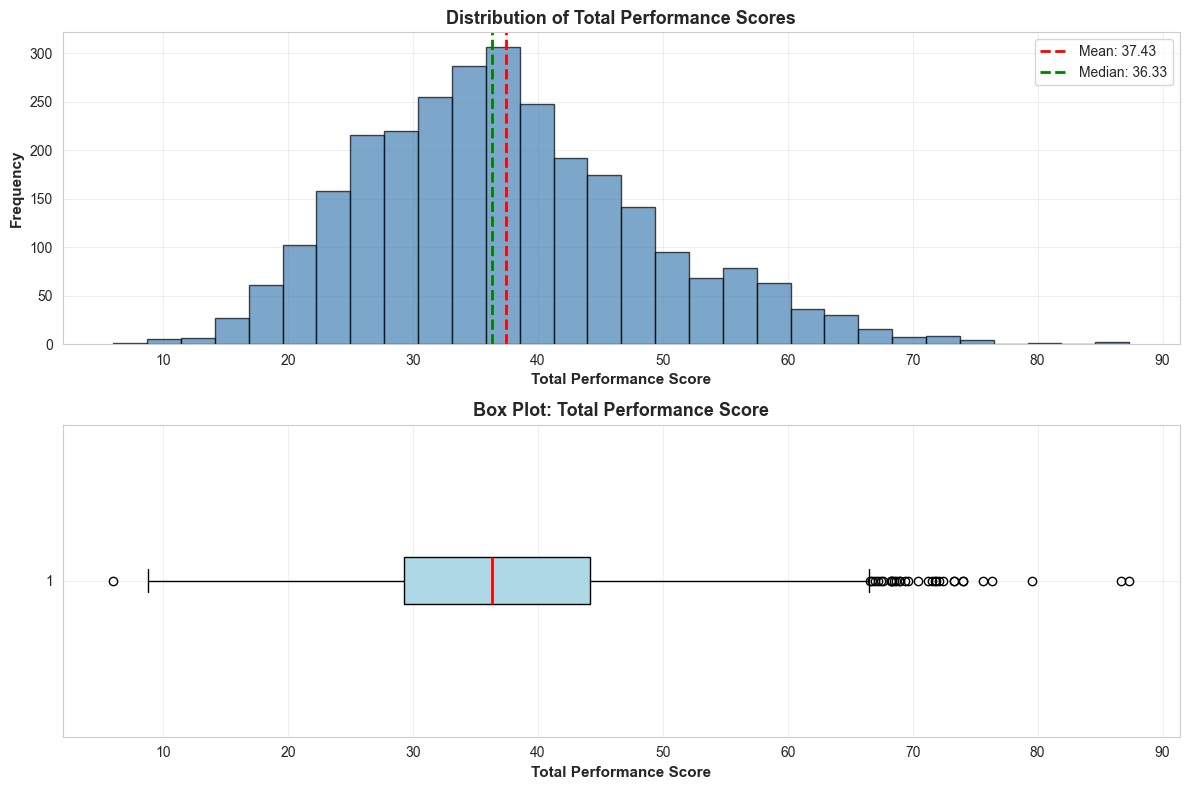

Statistics: Mean=37.43, Median=36.33, SD=11.37


In [7]:
# TOTAL PERFORMANCE SCORE DISTRIBUTION ANALYSIS
# Purpose: Visualize the distribution of hospital performance scores using histogram and box plot

# --- CREATE FIGURE WITH TWO SUBPLOTS ---
# 2 rows, 1 column layout for stacked visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# --- DATA PREPARATION ---
# Remove any missing values from TPS column for clean visualization
tps_data = df_analysis['Total_Performance_Score'].dropna()

# --- TOP PANEL: HISTOGRAM ---
# bins=30: divide data into 30 intervals for granular view
# alpha=0.7: slight transparency to soften the visual
axes[0].hist(tps_data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)

# Add vertical reference lines for mean and median
# Red dashed line for mean (average score)
axes[0].axvline(tps_data.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {tps_data.mean():.2f}')
# Green dashed line for median (middle value when sorted)
axes[0].axvline(tps_data.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {tps_data.median():.2f}')

# Formatting for histogram
axes[0].set_xlabel('Total Performance Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Total Performance Scores', fontsize=13, fontweight='bold')
axes[0].legend()  # Show legend with mean/median values
axes[0].grid(alpha=0.3)  # Light grid for readability

# --- BOTTOM PANEL: BOX PLOT ---
# Box plot shows: min, Q1, median, Q3, max, and outliers
# vert=False: horizontal orientation for easier comparison with histogram above
# patch_artist=True: allows filling the box with color
axes[1].boxplot([tps_data], vert=False, patch_artist=True, 
                boxprops=dict(facecolor='lightblue'),  # Fill box with light blue
                medianprops=dict(color='red', linewidth=2))  # Red line for median

# Formatting for box plot
axes[1].set_xlabel('Total Performance Score', fontsize=11, fontweight='bold')
axes[1].set_title('Box Plot: Total Performance Score', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

# --- FINAL ADJUSTMENTS ---
plt.tight_layout()  # Prevent subplot overlap
plt.savefig('tps_distribution.png', dpi=300, bbox_inches='tight')  # Save high-res image
plt.show()

# Print key statistics for reference
print(f"Statistics: Mean={tps_data.mean():.2f}, Median={tps_data.median():.2f}, SD={tps_data.std():.2f}")

## 4. Correlation Analysis

- We exclude HCAHPS_Score from correlation analysis to avoid redundancy
- HCAHPS_Score and Patient_Experience_Score measure similar concepts (patient satisfaction)
- Including both would create multicollinearity and skew results
- Patient_Experience_Score is more directly tied to the domain structure we're analyzing

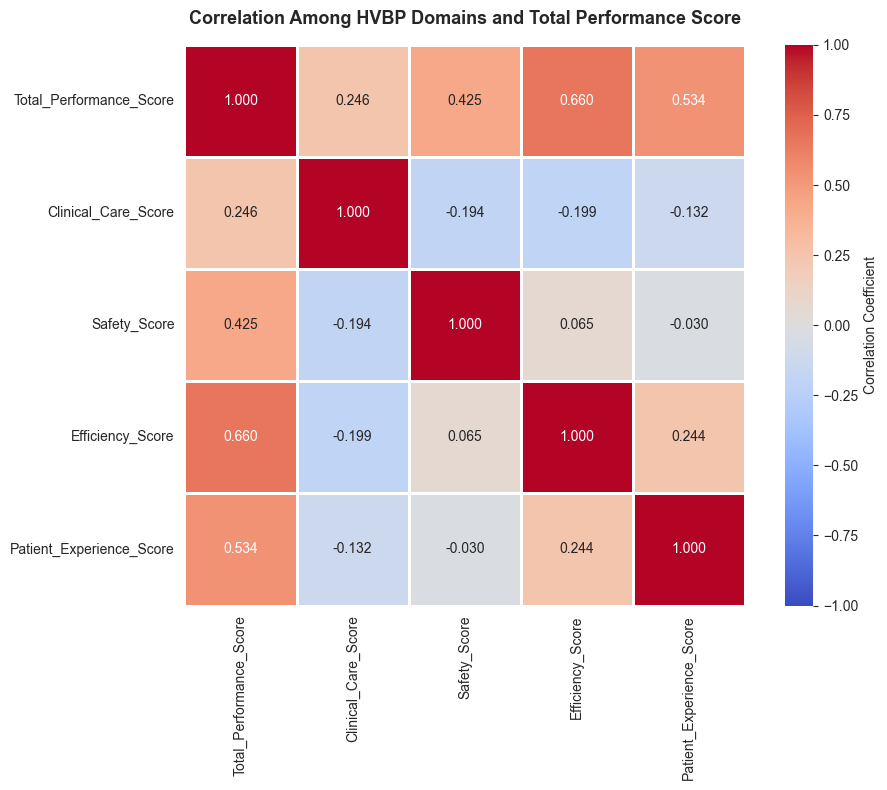

In [8]:
# Calculate correlation matrix (excluding HCAHPS to avoid redundancy)
corr_cols = ['Total_Performance_Score', 'Clinical_Care_Score', 
             'Safety_Score', 'Efficiency_Score', 'Patient_Experience_Score']
correlation_matrix = df_analysis[corr_cols].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, 
            cbar_kws={'label': 'Correlation Coefficient'}, vmin=-1, vmax=1)
plt.title('Correlation Among HVBP Domains and Total Performance Score', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

Hospitals with complete HCAHPS and Patient Experience data: 2800


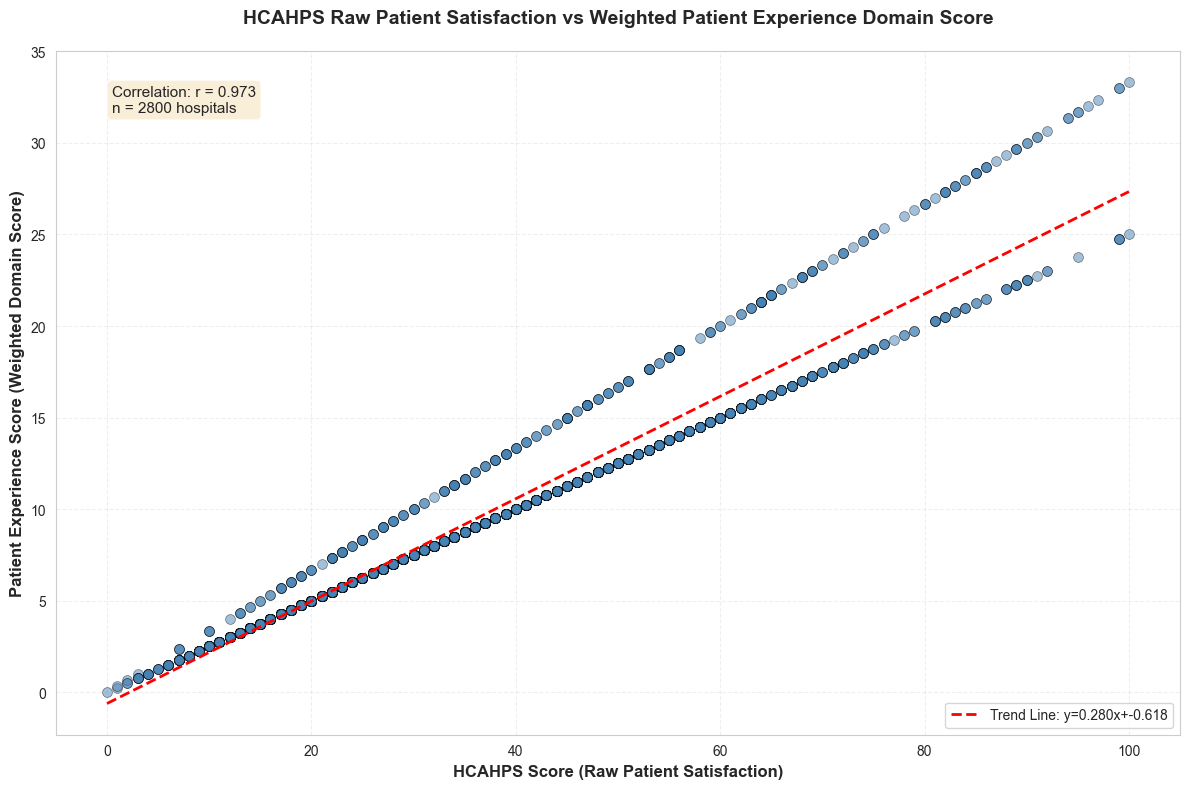

In [9]:
# HCAHPS vs PATIENT EXPERIENCE SCORE ANALYSIS
# Purpose: Examine the relationship between raw HCAHPS scores and the weighted Patient Experience domain score

# --- DATA PREPARATION ---
# Select only the columns needed for this analysis and remove rows with missing values
# We need both scores to plot the relationship
df_hcahps_analysis = df_analysis[['HCAHPS_Score', 'Patient_Experience_Score', 'Hospital Name']].dropna()
print(f"Hospitals with complete HCAHPS and Patient Experience data: {len(df_hcahps_analysis)}")

# --- CREATE SCATTER PLOT ---
plt.figure(figsize=(12, 8))

# Plot each hospital as a point
# alpha=0.5: semi-transparent to show overlapping points
# s=50: marker size
# edgecolors='black': adds black border around each point for visibility
plt.scatter(df_hcahps_analysis['HCAHPS_Score'], 
           df_hcahps_analysis['Patient_Experience_Score'],
           alpha=0.5, s=50, color='steelblue', edgecolors='black', linewidth=0.5)

# --- ADD TREND LINE ---
# np.polyfit: fits a polynomial of degree 1 (linear) to the data
# Returns coefficients [slope, intercept] for the equation y = slope*x + intercept
z = np.polyfit(df_hcahps_analysis['HCAHPS_Score'], df_hcahps_analysis['Patient_Experience_Score'], 1)
p = np.poly1d(z)  # Create a polynomial function from the coefficients

# Generate 100 evenly spaced x values for a smooth trend line
x_trend = np.linspace(df_hcahps_analysis['HCAHPS_Score'].min(), df_hcahps_analysis['HCAHPS_Score'].max(), 100)

# Plot the trend line: 'r--' means red dashed line
plt.plot(x_trend, p(x_trend), 'r--', linewidth=2, label=f'Trend Line: y={z[0]:.3f}x+{z[1]:.3f}')

# --- CALCULATE CORRELATION ---
# Pearson correlation coefficient measures linear relationship strength (-1 to 1)
# Values close to 1 indicate strong positive relationship
correlation = df_hcahps_analysis['HCAHPS_Score'].corr(df_hcahps_analysis['Patient_Experience_Score'])

# --- FORMATTING ---
plt.xlabel('HCAHPS Score (Raw Patient Satisfaction)', fontsize=12, fontweight='bold')
plt.ylabel('Patient Experience Score (Weighted Domain Score)', fontsize=12, fontweight='bold')
plt.title('HCAHPS Raw Patient Satisfaction vs Weighted Patient Experience Domain Score', 
          fontsize=14, fontweight='bold', pad=20)

# Add text annotation showing correlation and sample size
# transform=plt.gca().transAxes: positions text using relative coordinates (0-1)
# (0.05, 0.95) = 5% from left, 95% from bottom (top-left corner)
plt.text(0.05, 0.95, f'Correlation: r = {correlation:.3f}\nn = {len(df_hcahps_analysis)} hospitals',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.grid(True, alpha=0.3, linestyle='--')  # Light dashed grid for readability
plt.legend(loc='lower right', fontsize=10)  # Show trend line equation in legend
plt.tight_layout()  # Adjust spacing to prevent label cutoff
plt.show()

## 5. TPS Categorizes

Hospitals with complete data: 2807
Performance_Category
Medium Performers    1652
Low Performers       1051
High Performers       104
Name: count, dtype: int64


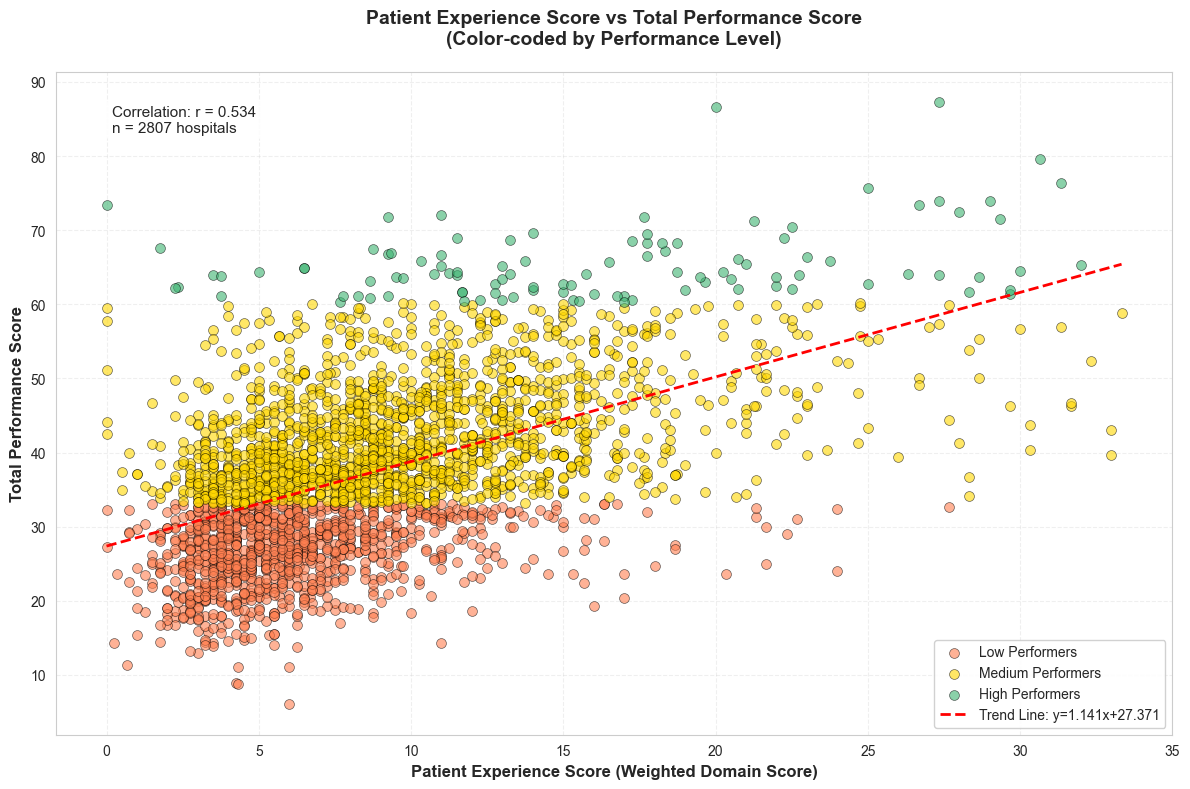

In [10]:
# PATIENT EXPERIENCE vs TOTAL PERFORMANCE SCORE (Color-coded)
# Purpose: Visualize how patient experience relates to overall hospital performance, grouped by performance level

# --- DATA PREPARATION ---
# Select relevant columns and remove rows with missing values
df_perf_analysis = df_analysis[['Patient_Experience_Score', 'Total_Performance_Score', 'Hospital Name', 'State']].dropna()

# Divide hospitals into 3 equal-width bins based on Total Performance Score
# pd.cut() automatically calculates bin edges from min to max
df_perf_analysis['Performance_Category'] = pd.cut(df_perf_analysis['Total_Performance_Score'], 
                                                   bins=3, labels=['Low Performers', 'Medium Performers', 'High Performers'])

# Print summary statistics
print(f"Hospitals with complete data: {len(df_perf_analysis)}")
print(df_perf_analysis['Performance_Category'].value_counts())

# --- CREATE SCATTER PLOT ---
plt.figure(figsize=(12, 8))

# Define color scheme: coral=low, gold=medium, green=high
colors_dict = {'Low Performers': 'coral', 'Medium Performers': 'gold', 'High Performers': 'mediumseagreen'}

# Plot each performance category separately to get different colors
for category in ['Low Performers', 'Medium Performers', 'High Performers']:
    mask = df_perf_analysis['Performance_Category'] == category  # Boolean mask for filtering
    plt.scatter(df_perf_analysis[mask]['Patient_Experience_Score'], 
               df_perf_analysis[mask]['Total_Performance_Score'],
               alpha=0.6, s=50, color=colors_dict[category],  # alpha=transparency, s=point size
               edgecolors='black', linewidth=0.5, label=category)

# --- ADD TREND LINE ---
# np.polyfit fits a 1st degree polynomial (linear regression) to the data
z = np.polyfit(df_perf_analysis['Patient_Experience_Score'], df_perf_analysis['Total_Performance_Score'], 1)
p = np.poly1d(z)  # Create polynomial function from coefficients

# Generate x values for smooth trend line
x_trend = np.linspace(df_perf_analysis['Patient_Experience_Score'].min(), 
                      df_perf_analysis['Patient_Experience_Score'].max(), 100)
plt.plot(x_trend, p(x_trend), 'r--', linewidth=2, label=f'Trend Line: y={z[0]:.3f}x+{z[1]:.3f}')

# --- ADD CORRELATION ANNOTATION ---
# Calculate Pearson correlation coefficient between the two variables
correlation = df_perf_analysis['Patient_Experience_Score'].corr(df_perf_analysis['Total_Performance_Score'])

# Add text box showing correlation and sample size
# transform=plt.gca().transAxes uses relative coordinates (0-1) instead of data coordinates
plt.text(0.05, 0.95, f'Correlation: r = {correlation:.3f}\nn = {len(df_perf_analysis)} hospitals',
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- FORMATTING ---
plt.xlabel('Patient Experience Score (Weighted Domain Score)', fontsize=12, fontweight='bold')
plt.ylabel('Total Performance Score', fontsize=12, fontweight='bold')
plt.title('Patient Experience Score vs Total Performance Score\n(Color-coded by Performance Level)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')  # Light grid for readability
plt.legend(loc='lower right', fontsize=10, framealpha=0.9)  # Semi-transparent legend
plt.tight_layout()  # Prevent label cutoff
plt.show()

## 6. Domain Contribution Analysis

**Key Insight:** We compare two perspectives:
1. **Raw Average Contribution:** How many points each domain contributes on average
2. **Standardized Coefficients:** Which domain has the most impact per unit of change (scale-adjusted)

This dual view reveals both absolute and relative importance of each domain.

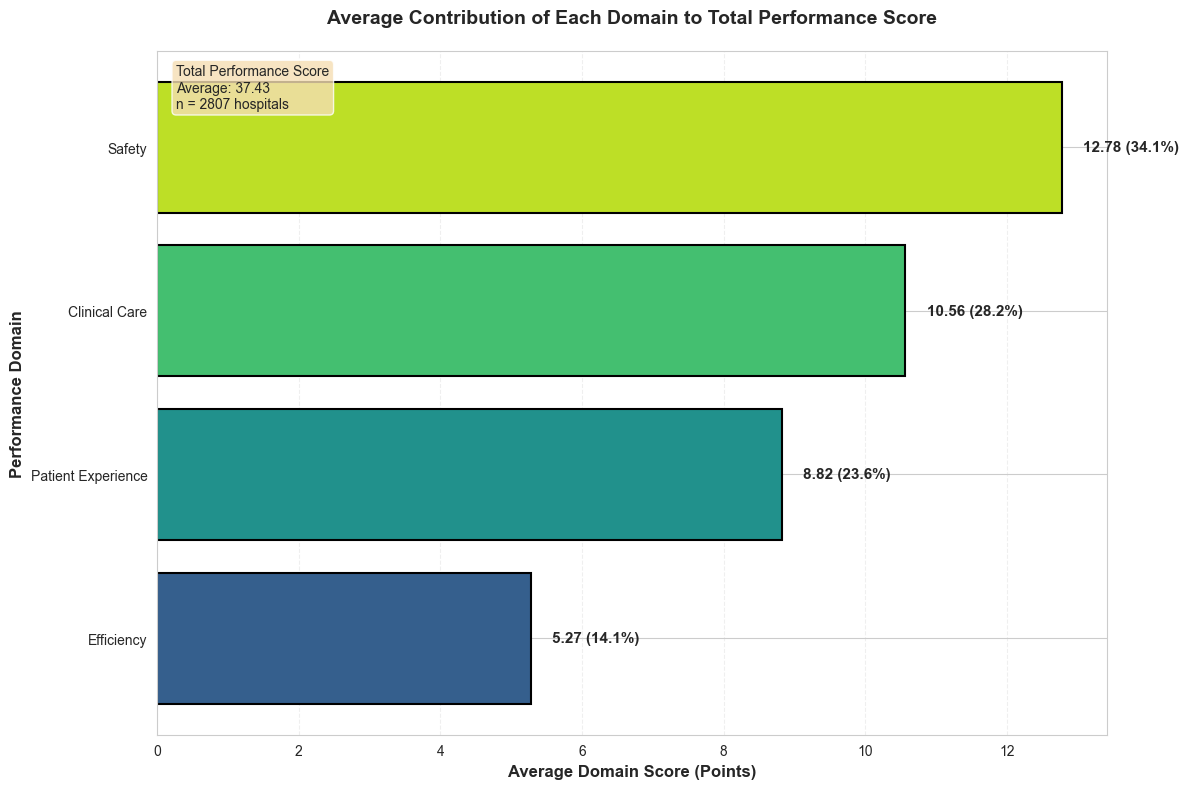

In [11]:
# DOMAIN CONTRIBUTION ANALYSIS
# Purpose: Calculate and visualize how much each performance domain contributes to the Total Performance Score on average

# --- DATA PREPARATION ---
# Select only the 4 domain scores and total score, removing any rows with missing values
# This ensures we're comparing complete records only
df_domain_analysis = df_analysis[['Clinical_Care_Score', 'Patient_Experience_Score', 
                                   'Safety_Score', 'Efficiency_Score', 'Total_Performance_Score']].dropna()

# --- CALCULATE DOMAIN AVERAGES ---
# Compute the mean score for each domain across all hospitals
# These represent the average points contributed by each domain
domain_means = {
    'Safety': df_domain_analysis['Safety_Score'].mean(),
    'Clinical Care': df_domain_analysis['Clinical_Care_Score'].mean(),
    'Patient Experience': df_domain_analysis['Patient_Experience_Score'].mean(),
    'Efficiency': df_domain_analysis['Efficiency_Score'].mean()
}

# Calculate the average Total Performance Score for reference
total_mean = df_domain_analysis['Total_Performance_Score'].mean()

# --- CALCULATE PERCENTAGE CONTRIBUTIONS ---
# Express each domain's average as a percentage of the total average score
# Formula: (Domain Average / Total Average) * 100
contribution_pct = {domain: (value / total_mean) * 100 for domain, value in domain_means.items()}

# --- CREATE SUMMARY DATAFRAME ---
# Organize results into a DataFrame for easier plotting
# Sort by Average_Score ascending so highest contributor appears at top of horizontal bar chart
contrib_df = pd.DataFrame({
    'Domain': list(domain_means.keys()),
    'Average_Score': list(domain_means.values()),
    'Contribution_%': list(contribution_pct.values())
}).sort_values('Average_Score', ascending=True)

# --- CREATE HORIZONTAL BAR CHART ---
fig, ax = plt.subplots(figsize=(12, 8))

# Use viridis colormap for visually appealing gradient
# np.linspace(0.3, 0.9) avoids the very dark and very light ends of the colormap
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(contrib_df)))

# Create horizontal bars with black edges for definition
bars = ax.barh(contrib_df['Domain'], contrib_df['Average_Score'], color=colors, edgecolor='black', linewidth=1.5)

# --- ADD VALUE LABELS ---
# Display score and percentage next to each bar
# enumerate gives us the y-position (i) for each bar
for i, (domain, score, pct) in enumerate(zip(contrib_df['Domain'], contrib_df['Average_Score'], contrib_df['Contribution_%'])):
    ax.text(score + 0.3, i, f'{score:.2f} ({pct:.1f}%)', va='center', ha='left', fontsize=11, fontweight='bold')

# --- AXIS LABELS AND TITLE ---
ax.set_xlabel('Average Domain Score (Points)', fontsize=12, fontweight='bold')
ax.set_ylabel('Performance Domain', fontsize=12, fontweight='bold')
ax.set_title('Average Contribution of Each Domain to Total Performance Score', fontsize=14, fontweight='bold', pad=20)

# --- ADD INFO BOX ---
# Display summary statistics in top-left corner
# transform=ax.transAxes uses relative coordinates (0-1) instead of data coordinates
info_text = f'Total Performance Score\nAverage: {total_mean:.2f}\nn = {len(df_domain_analysis)} hospitals'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- FINAL FORMATTING ---
ax.grid(True, alpha=0.3, linestyle='--', axis='x')  # Light vertical grid lines only
plt.tight_layout()  # Prevent label cutoff
plt.savefig('average_domain_contribution.png', dpi=300, bbox_inches='tight')  # Save high-res image
plt.show()

In [12]:
# PREPARE DATA FOR STANDARDIZED COEFFICIENT ANALYSIS
# Purpose: Calculate standardized coefficients to compare domain importance on a normalized scale
# This is needed for the dual-axis visualization in the next cell

# --- DEFINE COLUMN NAMES FOR MACHINE LEARNING ---
# These are the feature columns we'll use throughout the analysis
domain_cols = ['Clinical_Care_Score', 'Patient_Experience_Score', 'Safety_Score', 'Efficiency_Score']
domain_names = ['Clinical Care', 'Patient Experience', 'Safety', 'Efficiency']

# --- PREPARE COMPLETE DATASET ---
# Create df_complete with all domain scores and target variable (no missing values)
# This will be used for both standardized coefficients and Random Forest model
df_complete = df_analysis[domain_cols + ['Total_Performance_Score']].dropna()
print(f"Complete dataset for modeling: {len(df_complete)} hospitals")

# --- CALCULATE AVERAGE CONTRIBUTIONS ---
# How many raw points each domain contributes on average
avg_contributions = df_complete[domain_cols].mean()
avg_contributions.index = domain_names  # Rename index for display

# Calculate total average and percentage contributions
total_avg = avg_contributions.sum()
pct_contributions = (avg_contributions / total_avg * 100)

# --- CALCULATE STANDARDIZED COEFFICIENTS ---
# Standardized coefficients (β) show how much TPS changes per 1 SD change in each domain
# This normalizes for different scales, allowing fair comparison of importance

# Standardize features (subtract mean, divide by SD)
X = df_complete[domain_cols]
y = df_complete['Total_Performance_Score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit linear regression on standardized features
# The coefficients from this model are the standardized coefficients (β)
model = LinearRegression()
model.fit(X_scaled, y)
std_coefs = model.coef_

# --- DISPLAY RESULTS ---
print("\n--- Standardized Coefficient Analysis ---")
print("Standardized coefficients show impact per 1 SD change in each domain:")
for name, coef in zip(domain_names, std_coefs):
    print(f"  {name}: β = {coef:.4f}")
print(f"\nR² of linear model: {model.score(X_scaled, y):.4f}")

Complete dataset for modeling: 2807 hospitals

--- Standardized Coefficient Analysis ---
Standardized coefficients show impact per 1 SD change in each domain:
  Clinical Care: β = 5.9979
  Patient Experience: β = 5.3149
  Safety: β = 5.6941
  Efficiency: β = 7.0261

R² of linear model: 1.0000


## 7. Importance Scale Analysis

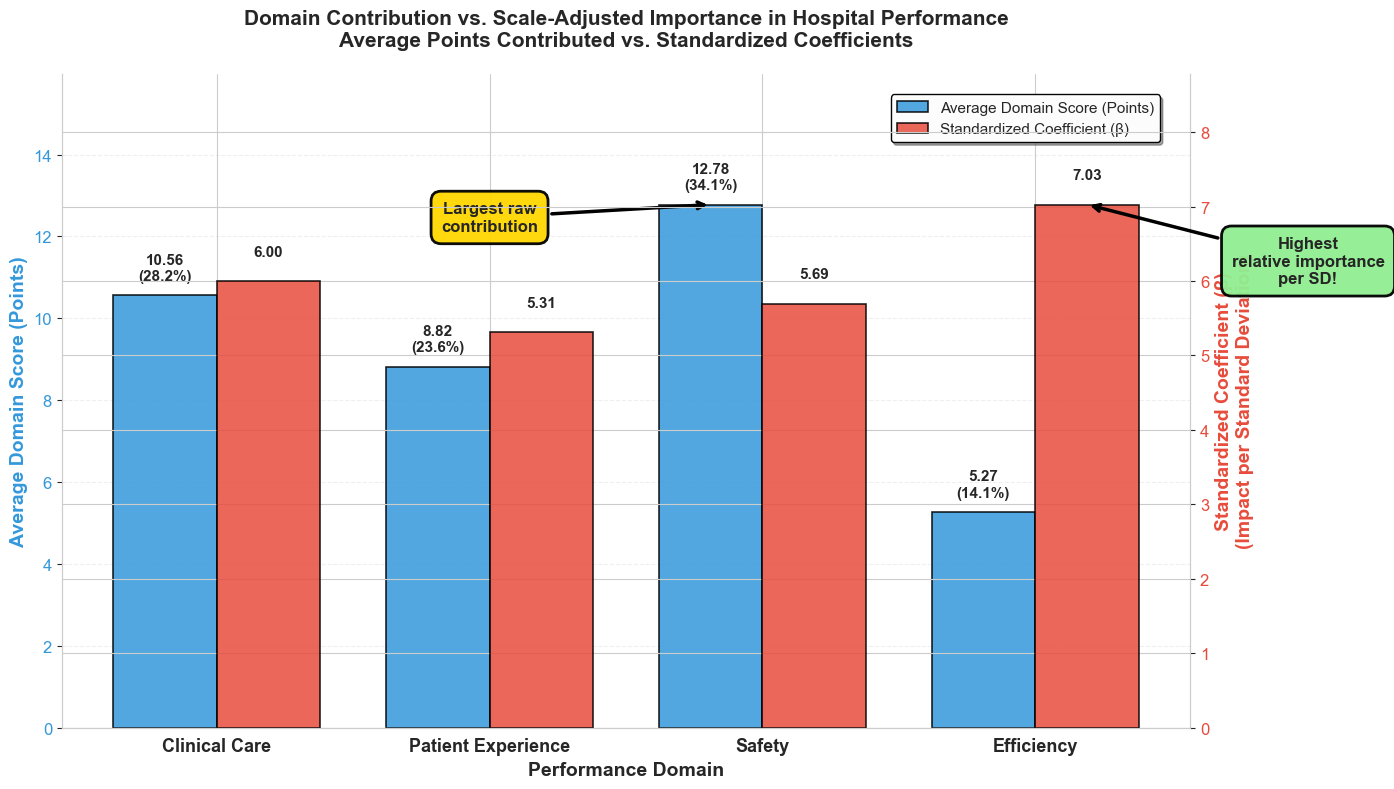


Domain Analysis Summary:
------------------------------------------------------------
Domain                  Avg Score   % of Total       β Coef
------------------------------------------------------------
Clinical Care               10.56        28.2%        5.998
Patient Experience           8.82        23.6%        5.315
Safety                      12.78        34.1%        5.694
Efficiency                   5.27        14.1%        7.026


In [13]:
# DUAL-AXIS VISUALIZATION: RAW CONTRIBUTION vs STANDARDIZED IMPORTANCE
# Purpose: Compare two different perspectives on domain importance:
#   1. Blue bars (left axis): Average points each domain contributes to TPS
#   2. Red bars (right axis): Standardized coefficients (β) showing relative impact per SD change
# This reveals that a domain can contribute many raw points but have less relative importance (or vice versa)

# --- CREATE FIGURE WITH DUAL Y-AXES ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# --- SETUP X-AXIS POSITIONS ---
# Create evenly spaced positions for the 4 domain categories
x = np.arange(len(domain_names))
width = 0.38  # Bar width - slightly less than 0.5 to leave gap between paired bars

# --- PRIMARY AXIS (LEFT): AVERAGE CONTRIBUTION - BLUE BARS ---
# These show how many raw points each domain contributes on average
# Position bars slightly left of center (x - width/2)
bars1 = ax1.bar(x - width/2, avg_contributions.values, width, 
                label='Average Domain Score (Points)', 
                color='#3498db', alpha=0.85, edgecolor='black', linewidth=1.2)

# Configure left y-axis styling
ax1.set_ylabel('Average Domain Score (Points)', fontsize=14, fontweight='bold', color='#3498db')
ax1.set_xlabel('Performance Domain', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(avg_contributions.values) * 1.25)  # Add 25% headroom for labels
ax1.tick_params(axis='y', labelsize=12, labelcolor='#3498db')  # Match label color to bars

# --- ADD VALUE LABELS ON BLUE BARS ---
# Display both the raw score and its percentage contribution
for i, (bar, pct) in enumerate(zip(bars1, pct_contributions.values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.3,
             f'{height:.2f}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- SECONDARY AXIS (RIGHT): STANDARDIZED COEFFICIENTS - RED BARS ---
# ax1.twinx() creates a second y-axis sharing the same x-axis
# Standardized coefficients (β) show impact per standard deviation change
# This normalizes for different scales, revealing true relative importance
ax2 = ax1.twinx()

# Position red bars slightly right of center (x + width/2)
bars2 = ax2.bar(x + width/2, std_coefs, width,
                label='Standardized Coefficient (β)', 
                color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=1.2)

# Configure right y-axis styling
ax2.set_ylabel('Standardized Coefficient (β)\n(Impact per Standard Deviation)', 
               fontsize=14, fontweight='bold', color='#e74c3c')
ax2.set_ylim(0, max(std_coefs) * 1.25)  # Add 25% headroom for labels
ax2.tick_params(axis='y', labelsize=12, labelcolor='#e74c3c')  # Match label color to bars

# --- ADD VALUE LABELS ON RED BARS ---
# Display the standardized coefficient value
for bar, coef in zip(bars2, std_coefs):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.3,
             f'{coef:.2f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- X-AXIS FORMATTING ---
# Set domain names as x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(domain_names, fontsize=13, fontweight='bold')

# --- CLEAN UP CHART APPEARANCE ---
# Hide top spines for cleaner look
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')  # Light horizontal grid lines

# --- TITLE ---
plt.title('Domain Contribution vs. Scale-Adjusted Importance in Hospital Performance\n' + 
          'Average Points Contributed vs. Standardized Coefficients',
          fontsize=15, fontweight='bold', pad=20)

# --- COMBINED LEGEND ---
# Merge legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper right',
           fontsize=11, 
           frameon=True, 
           shadow=True,
           framealpha=0.98,
           edgecolor='black',
           fancybox=True,
           bbox_to_anchor=(0.98, 0.98))  # Position in upper right corner

# --- FIND DOMAINS WITH HIGHEST VALUES ---
# Identify which domain has the highest raw contribution vs highest standardized coefficient
avg_vals_list = list(avg_contributions.values)
max_contrib_idx = avg_vals_list.index(max(avg_vals_list))  # Index of highest raw contributor
max_coef_idx = list(std_coefs).index(max(std_coefs))  # Index of highest standardized coefficient

# --- ANNOTATE HIGHEST RAW CONTRIBUTION ---
# Arrow pointing to the blue bar with largest average contribution
ax1.annotate('Largest raw\ncontribution', 
             xy=(max_contrib_idx - width/2, avg_vals_list[max_contrib_idx]),  # Arrow tip position
             xytext=(max_contrib_idx - 1.0, max(avg_vals_list) * 0.95),  # Text box position
             arrowprops=dict(arrowstyle='->', color='black', lw=2.5),
             fontsize=12, ha='center', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFD700',  # Gold background
                      alpha=0.95, edgecolor='black', linewidth=2))

# --- ANNOTATE HIGHEST STANDARDIZED COEFFICIENT ---
# Arrow pointing to the red bar with highest relative importance
ax2.annotate('Highest\nrelative importance\nper SD!', 
             xy=(max_coef_idx + width/2, std_coefs[max_coef_idx]),  # Arrow tip position
             xytext=(max_coef_idx + 1.0, max(std_coefs) * 0.85),  # Text box position
             arrowprops=dict(arrowstyle='->', color='black', lw=2.5),
             fontsize=12, ha='center', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#90EE90',  # Light green background
                      alpha=0.95, edgecolor='black', linewidth=2))

# --- FINAL FORMATTING AND SAVE ---
plt.tight_layout()  # Adjust spacing to prevent label cutoff
plt.savefig('domain_contribution_vs_importance.png', dpi=300, bbox_inches='tight')  # Save high-res image
plt.show()

# --- PRINT SUMMARY TABLE ---
# Display numerical summary for each domain
print("\nDomain Analysis Summary:")
print("-" * 60)
print(f"{'Domain':<20} {'Avg Score':>12} {'% of Total':>12} {'β Coef':>12}")
print("-" * 60)
for name, avg, pct, coef in zip(domain_names, avg_contributions.values, pct_contributions.values, std_coefs):
    print(f"{name:<20} {avg:>12.2f} {pct:>11.1f}% {coef:>12.3f}")

## 8. Machine Learning Model: Random Forest

**Why Random Forest?**
- Handles non-linear relationships well
- Provides feature importance rankings
- Robust to overfitting with proper tuning
- No need for feature scaling (unlike linear regression)

In [18]:
# RANDOM FOREST MODEL: TRAINING AND EVALUATION
# Purpose: Build a Random Forest model to predict Total Performance Score from domain scores
# Random Forest is an ensemble method that combines multiple decision trees for robust predictions

# --- PREPARE FEATURES AND TARGET ---
# X = feature matrix (4 domain scores)
# y = target variable (Total Performance Score)
# We use df_complete which was prepared earlier (no missing values)
X = df_complete[domain_cols]
y = df_complete['Total_Performance_Score']

print(f"Features: {domain_cols}")
print(f"Dataset size: {len(X)} hospitals")

# --- SPLIT DATA INTO TRAINING AND TESTING SETS ---
# 80% for training, 20% for testing
# random_state=42: ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set: {len(X_train)} hospitals")
print(f"Testing set: {len(X_test)} hospitals")

# --- TRAIN RANDOM FOREST MODEL ---
# n_estimators=100: Use 100 decision trees (more trees = more stable predictions)
# max_depth=10: Limit tree depth to prevent overfitting (trees won't grow too complex)
# random_state=42: ensures reproducible results
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# --- MAKE PREDICTIONS ON TEST SET ---
y_pred = rf_model.predict(X_test)

# --- EVALUATE MODEL PERFORMANCE ---
# R² Score: Proportion of variance explained (1.0 = perfect, 0 = no better than mean)
r2 = r2_score(y_test, y_pred)

# MAE (Mean Absolute Error): Average absolute difference between predicted and actual
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error): Penalizes large errors more than MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# --- DISPLAY RESULTS ---
print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"  R² Score: {r2:.4f}  (closer to 1 = better fit)")
print(f"  MAE:      {mae:.4f}  (average prediction error in points)")
print(f"  RMSE:     {rmse:.4f}  (root mean squared error)")
print("="*50)

Features: ['Clinical_Care_Score', 'Patient_Experience_Score', 'Safety_Score', 'Efficiency_Score']
Dataset size: 2807 hospitals

Training set: 2245 hospitals
Testing set: 562 hospitals

MODEL PERFORMANCE METRICS
  R² Score: 0.9608  (closer to 1 = better fit)
  MAE:      1.4314  (average prediction error in points)
  RMSE:     2.2710  (root mean squared error)


### Feature Importance

**Interpretation:** Feature importance shows which domains are most predictive of total performance. Higher values indicate greater predictive power.

Feature Importance from Random Forest:
           Feature  Importance
            Safety    0.183411
     Clinical Care    0.190394
Patient Experience    0.202910
        Efficiency    0.423285


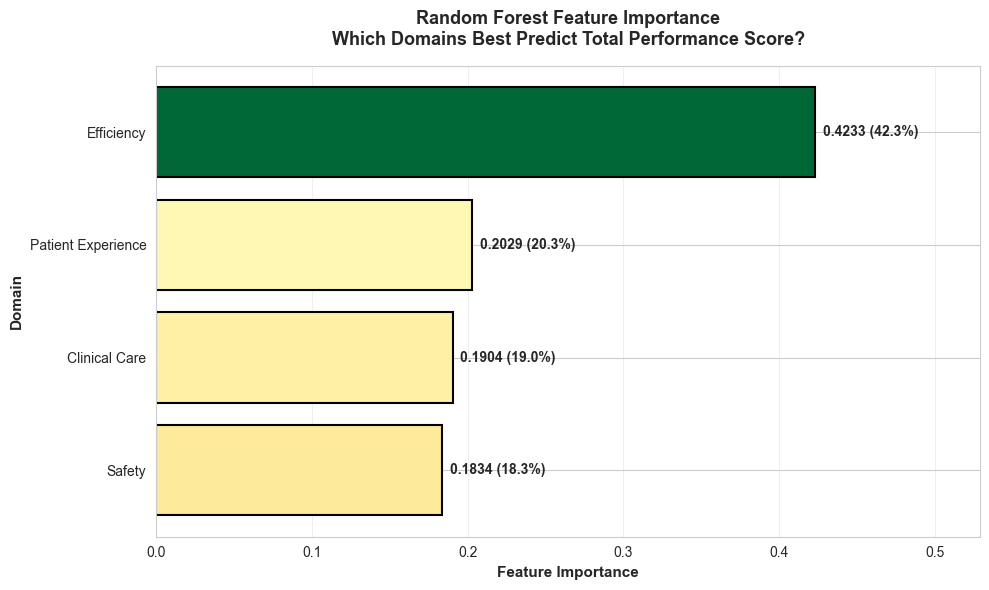

In [15]:
# RANDOM FOREST FEATURE IMPORTANCE VISUALIZATION
# Purpose: Show which domains are most predictive of Total Performance Score
# Feature importance measures how much each feature contributes to reducing prediction error
# Higher importance = domain has more influence on predictions

# --- PREPARE DATA ---
# Create dataframe with feature names and their importance scores from trained model
# rf_model.feature_importances_ returns array of importance values (sum to 1.0)
# Note: We use domain_names which matches the order of domain_cols
feature_importance = pd.DataFrame({
    'Feature': domain_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)  # Sort ascending for horizontal bar chart (bottom to top)

print("Feature Importance from Random Forest:")
print(feature_importance.to_string(index=False))

# --- CREATE HORIZONTAL BAR CHART ---
plt.figure(figsize=(10, 6))

# Color bars using RdYlGn colormap (Red-Yellow-Green)
# Normalize importance values to 0-1 range for color mapping
# Higher importance = greener color, lower = more red/yellow
colors = plt.cm.RdYlGn(feature_importance['Importance'] / feature_importance['Importance'].max())

# Create horizontal bar chart
# edgecolor='black' adds border around bars for visibility
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
                color=colors, edgecolor='black', linewidth=1.5)

# --- ADD VALUE LABELS ---
# Display importance value and percentage next to each bar
for i, (feat, imp) in enumerate(zip(feature_importance['Feature'], feature_importance['Importance'])):
    plt.text(imp + 0.005, i, f'{imp:.4f} ({imp*100:.1f}%)', va='center', fontsize=10, fontweight='bold')

# --- FORMATTING ---
plt.xlabel('Feature Importance', fontsize=11, fontweight='bold')
plt.ylabel('Domain', fontsize=11, fontweight='bold')
plt.title('Random Forest Feature Importance\nWhich Domains Best Predict Total Performance Score?', 
          fontsize=13, fontweight='bold', pad=15)
plt.grid(alpha=0.3, axis='x')  # Light vertical grid lines only
plt.xlim(0, feature_importance['Importance'].max() * 1.25)  # Add headroom for labels
plt.tight_layout()  # Prevent label cutoff
plt.savefig('feature_importance_rf.png', dpi=300, bbox_inches='tight')  # Save high-res image
plt.show()

### Model Validation: Actual vs Predicted

**Purpose:** This scatter plot validates our model. Points close to the red diagonal line indicate accurate predictions.

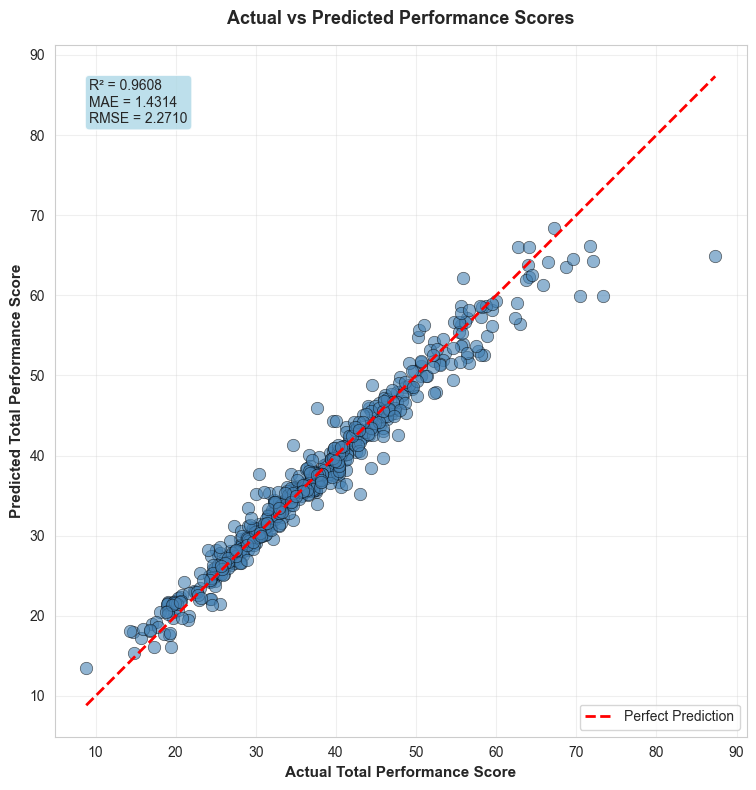

In [16]:
# MODEL VALIDATION: ACTUAL VS PREDICTED SCATTER PLOT
# Purpose: Visualize how well the model predictions match actual values Points close to the diagonal line indicate accurate predictions

# --- CREATE SCATTER PLOT ---
plt.figure(figsize=(8, 8))

# Plot each test hospital as a point
# x-axis: actual TPS, y-axis: predicted TPS
# alpha=0.6: semi-transparent to show overlapping points
# s=80: marker size for visibility
plt.scatter(y_test, y_pred, alpha=0.6, s=80, color='steelblue', 
            edgecolors='black', linewidth=0.5)

# --- ADD PERFECT PREDICTION LINE ---
# This 45-degree diagonal represents where predictions would perfectly match actual values
# Points above the line = model over-predicted, below = under-predicted
min_val = min(y_test.min(), y_pred.min())  # Find the minimum value for both axes
max_val = max(y_test.max(), y_pred.max())  # Find the maximum value for both axes
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
         label='Perfect Prediction')

# --- FORMATTING ---
plt.xlabel('Actual Total Performance Score', fontsize=11, fontweight='bold')
plt.ylabel('Predicted Total Performance Score', fontsize=11, fontweight='bold')
plt.title('Actual vs Predicted Performance Scores', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# set_aspect('equal'): ensures 1:1 ratio so diagonal line appears at true 45 degrees
plt.gca().set_aspect('equal', adjustable='box')

# --- ADD PERFORMANCE METRICS TEXT BOX ---
# Display key metrics in top-left corner for quick reference
# R² = how much variance is explained (closer to 1 = better)
# MAE = average absolute prediction error
# RMSE = root mean squared error (penalizes large errors more)
info_text = f'R² = {r2:.4f}\nMAE = {mae:.4f}\nRMSE = {rmse:.4f}'
plt.text(0.05, 0.95, info_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()  # Adjust spacing to prevent label cutoff
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')  # Save high-res image
plt.show()